Hydrophobicity                0.584126
Hydrophobic  density          0.514599
RK_Hydrophobic ratio Log1p   -0.495331
STRK_ratio Log1p              0.304835
Length                       -0.270383
Hydrophobic_ moment          -0.095001
Netcharge                     0.062003
Name: PLS1_loading, dtype: float64

R2 (NEES ~ PLS1): 0.6210380965743219


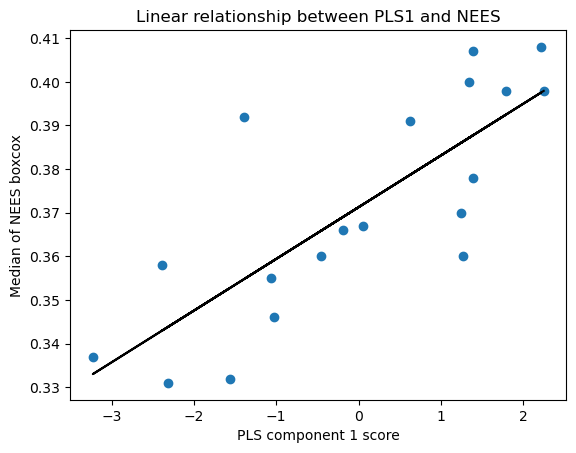

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("./SourceData/AH_selected.csv")
df.columns = [c.replace("\n", " ").strip() for c in df.columns]

y = df["Median of NEES boxcox"].values
X = df.drop(columns=["Median of NEES boxcox"])

# Standardize X
Xs = StandardScaler().fit_transform(X)

# Fit 1-component PLS
pls1 = PLSRegression(n_components=1)
pls1.fit(Xs, y)

# Extract PLS1 scores
t1 = pls1.x_scores_[:, 0].reshape(-1, 1)
df_output = pd.DataFrame({"PLS1_score": t1.ravel(), "Median of NEES boxcox": y.ravel()})
df_output.to_csv("./Output/pls1_scores.csv", index=False)

# Extract X loadings for component 1
loadings = pd.Series(
    pls1.x_loadings_[:, 0],
    index=X.columns,
    name="PLS1_loading"
)

# Sort by absolute magnitude
loadings_sorted = loadings.reindex(loadings.abs().sort_values(ascending=False).index)# Save loadings to CSV
loadings_sorted.to_csv("./Output/pls1_loadings_selected.csv", header=True)
print(loadings_sorted)


# Linear regression: NEES ~ PLS1
lm = LinearRegression().fit(t1, y)
yhat = lm.predict(t1)
r2_pls1 = r2_score(y, yhat)
print("\nR2 (NEES ~ PLS1):", r2_pls1)

# Plot
plt.scatter(t1, y)
plt.plot(t1, yhat, color="black")
plt.xlabel("PLS component 1 score")
plt.ylabel("Median of NEES boxcox")
plt.title("Linear relationship between PLS1 and NEES")
plt.show()
